In [3]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchinfo import summary
import numpy as np
import os

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [4]:
import zipfile
if not os.path.exists(r'E:\ml\dataset\cv\PetImages'):
    with zipfile.ZipFile(r'E:\ml\dataset\cv\kagglecatsanddogs_5340.zip', 'r') as zip_ref:
        zip_ref.extractall(r'E:\ml\dataset\cv')

In [5]:
from PIL import Image
import glob

def check_image(fn):
    try:
        im = Image.open(fn)
        im.verify()
        return True
    except:
        return False
    
def check_image_dir(path):
    for fn in glob.glob(path):
        if not check_image(fn):
            print("Corrupt image: {}".format(fn))
            os.remove(fn)

In [6]:
check_image_dir(r'E:\ml\dataset\cv\PetImages\Cat\*.jpg')
check_image_dir(r'E:\ml\dataset\cv\PetImages\Dog\*.jpg')

d:\projects\github_me\pytorch\LearnPyTorch\venv\lib\site-packages\PIL\TiffImagePlugin.py:845: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [7]:
def display_dataset(dataset, n=10,classes=None):
    fig,ax = plt.subplots(1,n,figsize=(15,3))
    mn = min([dataset[i][0].min() for i in range(n)])
    mx = max([dataset[i][0].max() for i in range(n)])
    for i in range(n):
        ax[i].imshow(np.transpose((dataset[i][0]-mn)/(mx-mn),(1,2,0)))
        ax[i].axis('off')
        if classes:
            ax[i].set_title(classes[dataset[i][1]])

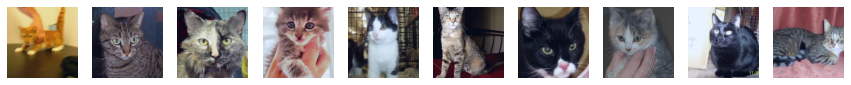

In [8]:
std_normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
trans = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(), 
        std_normalize])
dataset = torchvision.datasets.ImageFolder(r'E:\ml\dataset\cv\PetImages',transform=trans)
trainset, testset = torch.utils.data.random_split(dataset,[20000,len(dataset)-20000])

display_dataset(dataset)

In [9]:
vgg = torchvision.models.vgg16(pretrained=True).to(device)

In [11]:
sample_image = dataset[0][0].unsqueeze(0).to(device)
res = vgg(sample_image)
print(res[0].argmax())

tensor(282, device='cuda:0')


In [12]:
import json, requests
class_map = requests.get("https://mslearntensorflowlp.blob.core.windows.net/metadata/imagenet_class_index.json").json()
class_map = { int(k) : v for k,v in class_map.items() }

class_map[res[0].argmax().item()]

['n02123159', 'tiger_cat']

In [13]:
summary(vgg,input_size=(1,3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      --                        --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         1,792
│    └─ReLU: 2-2                         [1, 64, 224, 224]         --
│    └─Conv2d: 2-3                       [1, 64, 224, 224]         36,928
│    └─ReLU: 2-4                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-5                    [1, 64, 112, 112]         --
│    └─Conv2d: 2-6                       [1, 128, 112, 112]        73,856
│    └─ReLU: 2-7                         [1, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [1, 128, 112, 112]        147,584
│    └─ReLU: 2-9                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [1, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [1, 256, 56, 56]          29

torch.Size([1, 512, 7, 7])


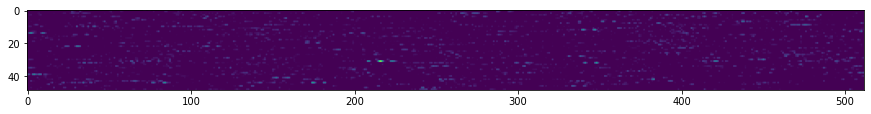

In [14]:
res = vgg.features(sample_image).cpu()
plt.figure(figsize=(15,3))
plt.imshow(res.detach().view(-1,512))
print(res.size())

In [15]:
bs = 8
dl = torch.utils.data.DataLoader(dataset,batch_size=bs,shuffle=True)
num = bs*100
feature_tensor = torch.zeros(num,512*7*7).to(device)
label_tensor = torch.zeros(num).to(device)
i = 0
for x,l in dl:
    with torch.no_grad():
        f = vgg.features(x.to(device))
        feature_tensor[i:i+bs] = f.view(bs,-1)
        label_tensor[i:i+bs] = l
        i+=bs
        print('.',end='')
        if i>=num:
            break

....................................................................................................

In [16]:
def train_epoch(net,dataloader,lr=0.01,optimizer=None,loss_fn = nn.NLLLoss()):
    optimizer = optimizer or torch.optim.Adam(net.parameters(),lr=lr)
    net.train()
    total_loss,acc,count = 0,0,0
    for features,labels in dataloader:
        optimizer.zero_grad()
        lbls = labels.to(device)
        out = net(features.to(device))
        loss = loss_fn(out,lbls) #cross_entropy(out,labels)
        loss.backward()
        optimizer.step()
        total_loss+=loss
        _,predicted = torch.max(out,1)
        acc+=(predicted==lbls).sum()
        count+=len(labels)
    return total_loss.item()/count, acc.item()/count

def validate(net, dataloader,loss_fn=nn.NLLLoss()):
    net.eval()
    count,acc,loss = 0,0,0
    with torch.no_grad():
        for features,labels in dataloader:
            lbls = labels.to(device)
            out = net(features.to(device))
            loss += loss_fn(out,lbls) 
            pred = torch.max(out,1)[1]
            acc += (pred==lbls).sum()
            count += len(labels)
    return loss.item()/count, acc.item()/count

def train(net,train_loader,test_loader,optimizer=None,lr=0.01,epochs=10,loss_fn=nn.NLLLoss()):
    optimizer = optimizer or torch.optim.Adam(net.parameters(),lr=lr)
    res = { 'train_loss' : [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for ep in range(epochs):
        tl,ta = train_epoch(net,train_loader,optimizer=optimizer,lr=lr,loss_fn=loss_fn)
        vl,va = validate(net,test_loader,loss_fn=loss_fn)
        print(f"Epoch {ep:2}, Train acc={ta:.3f}, Val acc={va:.3f}, Train loss={tl:.3f}, Val loss={vl:.3f}")
        res['train_loss'].append(tl)
        res['train_acc'].append(ta)
        res['val_loss'].append(vl)
        res['val_acc'].append(va)
    return res

def train_long(net,train_loader,test_loader,epochs=5,lr=0.01,optimizer=None,loss_fn = nn.NLLLoss(),print_freq=10):
    optimizer = optimizer or torch.optim.Adam(net.parameters(),lr=lr)
    for epoch in range(epochs):
        net.train()
        total_loss,acc,count = 0,0,0
        for i, (features,labels) in enumerate(train_loader):
            lbls = labels.to(device)
            optimizer.zero_grad()
            out = net(features.to(device))
            loss = loss_fn(out,lbls)
            loss.backward()
            optimizer.step()
            total_loss+=loss
            _,predicted = torch.max(out,1)
            acc+=(predicted==lbls).sum()
            count+=len(labels)
            if i%print_freq==0:
                print("Epoch {}, minibatch {}: train acc = {}, train loss = {}".format(epoch,i,acc.item()/count,total_loss.item()/count))
        vl,va = validate(net,test_loader,loss_fn)
        print("Epoch {} done, validation acc = {}, validation loss = {}".format(epoch,va,vl))

In [17]:
vgg_dataset = torch.utils.data.TensorDataset(feature_tensor,label_tensor.to(torch.long))
train_ds, test_ds = torch.utils.data.random_split(vgg_dataset,[700,100])

train_loader = torch.utils.data.DataLoader(train_ds,batch_size=32)
test_loader = torch.utils.data.DataLoader(test_ds,batch_size=32)

net = torch.nn.Sequential(torch.nn.Linear(512*7*7,2),torch.nn.LogSoftmax()).to(device)

history = train(net,train_loader,test_loader)

d:\projects\github_me\pytorch\LearnPyTorch\venv\lib\site-packages\torch\nn\modules\container.py:141: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  input = module(input)


Epoch  0, Train acc=0.899, Val acc=0.960, Train loss=0.078, Val loss=0.071
Epoch  1, Train acc=0.981, Val acc=0.980, Train loss=0.016, Val loss=0.037
Epoch  2, Train acc=0.986, Val acc=0.930, Train loss=0.009, Val loss=0.109
Epoch  3, Train acc=0.976, Val acc=0.980, Train loss=0.020, Val loss=0.041
Epoch  4, Train acc=0.997, Val acc=0.970, Train loss=0.000, Val loss=0.048
Epoch  5, Train acc=0.999, Val acc=0.990, Train loss=0.000, Val loss=0.028
Epoch  6, Train acc=1.000, Val acc=0.990, Train loss=0.000, Val loss=0.026
Epoch  7, Train acc=1.000, Val acc=0.990, Train loss=0.000, Val loss=0.025
Epoch  8, Train acc=1.000, Val acc=0.990, Train loss=0.000, Val loss=0.025
Epoch  9, Train acc=1.000, Val acc=0.990, Train loss=0.000, Val loss=0.025


In [18]:
print(vgg)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [19]:
vgg.classifier = torch.nn.Linear(25088, 2).to(device)

for x in vgg.features.parameters():
    x.requires_grad = False

summary(vgg, (1, 3, 244, 244))

Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      --                        --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 64, 244, 244]         (1,792)
│    └─ReLU: 2-2                         [1, 64, 244, 244]         --
│    └─Conv2d: 2-3                       [1, 64, 244, 244]         (36,928)
│    └─ReLU: 2-4                         [1, 64, 244, 244]         --
│    └─MaxPool2d: 2-5                    [1, 64, 122, 122]         --
│    └─Conv2d: 2-6                       [1, 128, 122, 122]        (73,856)
│    └─ReLU: 2-7                         [1, 128, 122, 122]        --
│    └─Conv2d: 2-8                       [1, 128, 122, 122]        (147,584)
│    └─ReLU: 2-9                         [1, 128, 122, 122]        --
│    └─MaxPool2d: 2-10                   [1, 128, 61, 61]          --
│    └─Conv2d: 2-11                      [1, 256, 61, 61]    

In [20]:
trainset, testset = torch.utils.data.random_split(dataset,[20000,len(dataset)-20000])
train_loader = torch.utils.data.DataLoader(trainset,batch_size=16)
test_loader = torch.utils.data.DataLoader(testset,batch_size=16)

train_long(vgg,train_loader,test_loader,loss_fn=torch.nn.CrossEntropyLoss(),epochs=1,print_freq=90)

Epoch 0, minibatch 0: train acc = 0.6875, train loss = 0.05491117388010025
Epoch 0, minibatch 90: train acc = 0.9478021978021978, train loss = 0.12947491237095424
Epoch 0, minibatch 180: train acc = 0.9630524861878453, train loss = 0.10631679303079679
Epoch 0, minibatch 270: train acc = 0.9626383763837638, train loss = 0.12426311591454538
Epoch 0, minibatch 360: train acc = 0.96398891966759, train loss = 0.1394722005997338
Epoch 0, minibatch 450: train acc = 0.9661862527716186, train loss = 0.1375994544864494
Epoch 0, minibatch 540: train acc = 0.9664972273567468, train loss = 0.1427149887225985
Epoch 0, minibatch 630: train acc = 0.9684033280507132, train loss = 0.13909609835423684
Epoch 0, minibatch 720: train acc = 0.9692267683772539, train loss = 0.15401620640007369
Epoch 0, minibatch 810: train acc = 0.969405055487053, train loss = 0.15517559122069108
Epoch 0, minibatch 900: train acc = 0.9707269700332963, train loss = 0.15063071806608108
Epoch 0, minibatch 990: train acc = 0.9711

d:\projects\github_me\pytorch\LearnPyTorch\venv\lib\site-packages\PIL\TiffImagePlugin.py:845: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 0 done, validation acc = 0.9809923969587835, validation loss = 0.1612962079362995


In [21]:
torch.save(vgg,r'E:\ml\model\cv\test\cats_dogs.pth')

In [24]:
vgg = torch.load(r'E:\ml\model\cv\test\cats_dogs.pth').to(device)

In [25]:
for x in vgg.features.parameters():
    x.requires_grad = True

In [26]:
train_long(vgg,train_loader,test_loader,loss_fn=torch.nn.CrossEntropyLoss(),epochs=1,print_freq=90,lr=0.0001)

Epoch 0, minibatch 0: train acc = 1.0, train loss = 0.0
Epoch 0, minibatch 90: train acc = 0.9340659340659341, train loss = 0.1923998528784448
Epoch 0, minibatch 180: train acc = 0.9402624309392266, train loss = 0.12126466319047285
Epoch 0, minibatch 270: train acc = 0.941190036900369, train loss = 0.09140956357836283
Epoch 0, minibatch 360: train acc = 0.9409626038781164, train loss = 0.07382025679062608
Epoch 0, minibatch 450: train acc = 0.9420731707317073, train loss = 0.06237061747954849
Epoch 0, minibatch 540: train acc = 0.9453558225508318, train loss = 0.05386151227404582
Epoch 0, minibatch 630: train acc = 0.9477020602218701, train loss = 0.047251445933491606
Epoch 0, minibatch 720: train acc = 0.9494625520110958, train loss = 0.042757272389659276
Epoch 0, minibatch 810: train acc = 0.9508323057953144, train loss = 0.03891046479362742
Epoch 0, minibatch 900: train acc = 0.9519977802441731, train loss = 0.0356386504347925
Epoch 0, minibatch 990: train acc = 0.9535822401614531, 

d:\projects\github_me\pytorch\LearnPyTorch\venv\lib\site-packages\PIL\TiffImagePlugin.py:845: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 0 done, validation acc = 0.9673869547819127, validation loss = 0.006925053193884976


In [27]:
resnet = torchvision.models.resnet18()
print(resnet)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  